In [1]:
adc_filename = "Test_2025-08-24-13-52-45\\raw_data.bin" 
# adc2_filename = "raw_data_5m.bin"
# adc3_filename = "chair_5m_1200.bin" 

# Parsing ADC Raw IQ Data Received via LVDS

## Parsing ADC Raw IQ Data Received via LVDS Using numpy

### Load relevant libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

### Set corresponding parameters

In [3]:
# You can fill in the parameters according to the cfg file (the terminal will also print them when running the acquisition program)
# ADC_PARAMS={'chirps': 128, 'rx': 4, 'tx': 3, 'samples': 256, 'IQ': 2, 'bytes': 2, 'startFreq': 76, 'idleTime': 7.0, 'adc_valid_start_time': 4.0, 'rampEndTime': 15.53, 'freq_slope': 265, 'txStartTime': 1.0, 'sample_rate': 22500, 'frame_periodicity': 8.952}

# You can also automatically read parameters from the cfg file
from mmwave.dataloader import DCA1000
_, _, ADC_PARAMS, _ = DCA1000.AWR2243_read_config("configFiles/AWR2243_mmwaveconfig.txt")
print(ADC_PARAMS)

{'chirps': 128, 'rx': 4, 'tx': 1, 'samples': 256, 'IQ': 2, 'bytes': 2, 'startFreq': 77.00025880336761, 'idleTime': 100.0, 'adc_valid_start_time': 6.0, 'rampEndTime': 60.0, 'freq_slope': 29.98173236846924, 'txStartTime': 0.0, 'sample_rate': 10000, 'frame_periodicity': 70.0}


### Load and parse the saved bin data

In [4]:
adc_data = np.fromfile(adc_filename, dtype=np.int16)
# adc_data2 = np.fromfile(adc2_filename, dtype=np.int16)
# adc_data3 = np.fromfile(adc3_filename, dtype=np.int16)

adc_data=np.reshape(adc_data,(-1,ADC_PARAMS['chirps'],ADC_PARAMS['tx'],ADC_PARAMS['samples'],ADC_PARAMS['IQ'],ADC_PARAMS['rx']))
# adc_data2=np.reshape(adc_data2,(-1,ADC_PARAMS['chirps'],ADC_PARAMS['tx'],ADC_PARAMS['samples'],ADC_PARAMS['IQ'],ADC_PARAMS['rx']))
# adc_data3=np.reshape(adc_data3,(-1,ADC_PARAMS['chirps'],ADC_PARAMS['tx'],ADC_PARAMS['samples'],ADC_PARAMS['IQ'],ADC_PARAMS['rx']))
print(adc_data.shape)

adc_data=np.transpose(adc_data,(0,1,2,5,3,4))
# adc_data2=np.transpose(adc_data2,(0,1,2,5,3,4))
# adc_data3=np.transpose(adc_data3,(0,1,2,5,3,4))
#100Frames*128Chirps*3TX*4RX(Lanes)*256Samples*2IQ
print(adc_data.shape)


adc_data = (1j * adc_data[...,1] + adc_data[...,0]).astype(np.complex64) 
# adc_data2 = (1j * adc_data2[...,1] + adc_data2[...,0]).astype(np.complex64)
# adc_data3 = (1j * adc_data3[...,1] + adc_data3[...,0]).astype(np.complex64)
#100Frames*128Chirps*3TX*4RX*256Samples复数形式
print(adc_data.shape)

(8, 128, 1, 256, 2, 4)
(8, 128, 1, 4, 256, 2)
(8, 128, 1, 4, 256)


### 绘制时域IQ波形

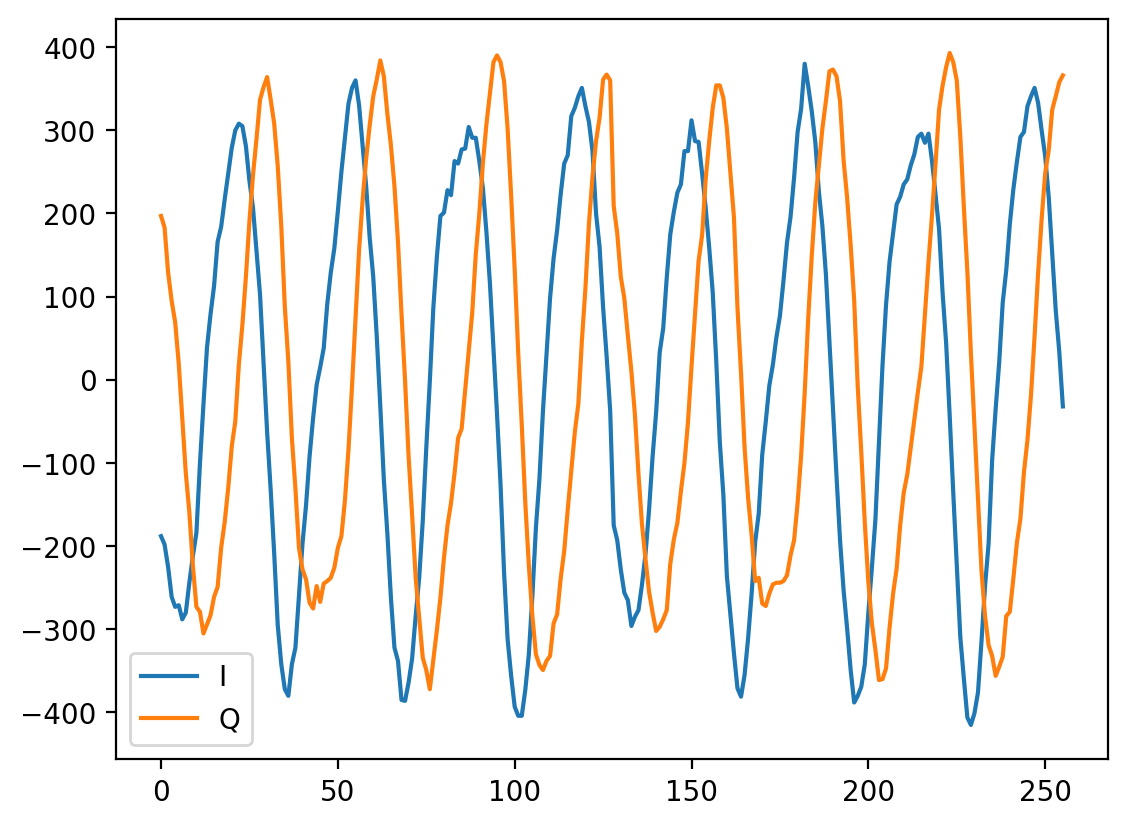

In [5]:
frame_index = 5 # You can change this to visualize different frames
plt.plot(np.real(adc_data[frame_index,0,0,0,:]),label="I") # I路
plt.plot(np.imag(adc_data[frame_index,0,0,0,:]),label="Q") # Q路
plt.legend()
plt.show()

### 计算Range-FFT

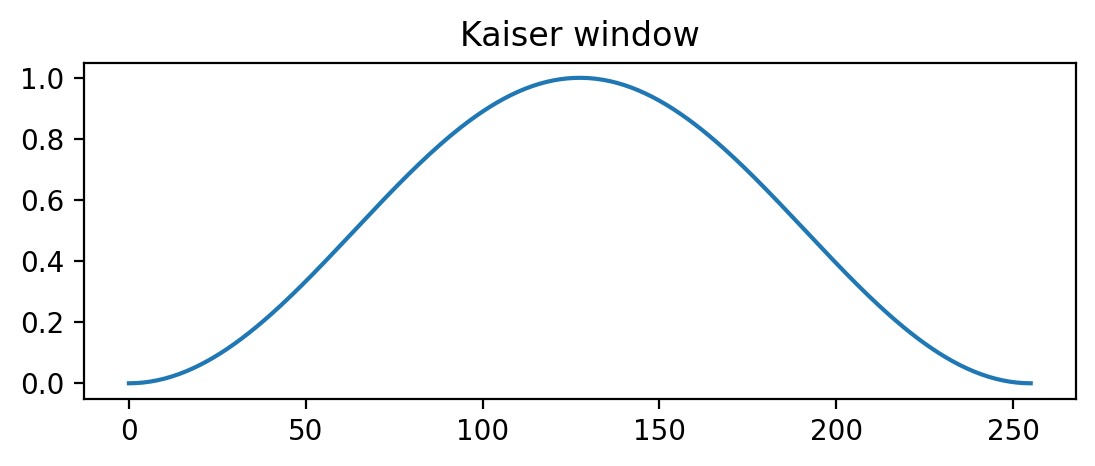

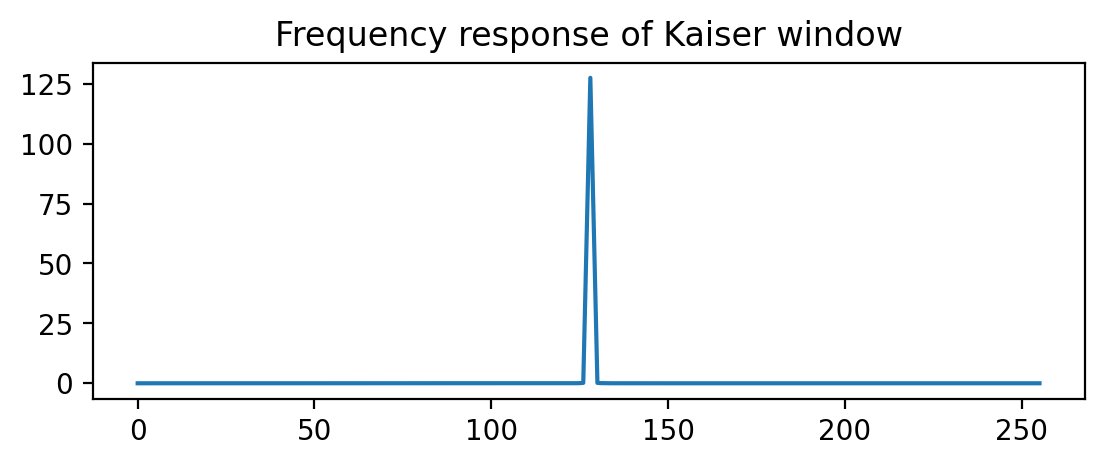

In [27]:
# window=np.kaiser(ADC_PARAMS['samples'], 4)
window=np.hanning(ADC_PARAMS['samples'])
window_fft = np.fft.fft(window, ADC_PARAMS['samples'])
window_fft = np.fft.fftshift(window_fft)

plt.subplot(2,1,1)
plt.plot(window)
plt.title("Kaiser window")
plt.show()

plt.subplot(2,1,2)
plt.plot(np.abs(window_fft))
plt.title("Frequency response of Kaiser window")
plt.show()



# window=np.tile(window,(adc_data.shape[0],adc_data.shape[1],adc_data.shape[2],adc_data.shape[3],1))

In [28]:
adc_data_w=adc_data*window

Range Resolution: 0.19543150235581797 [meters]


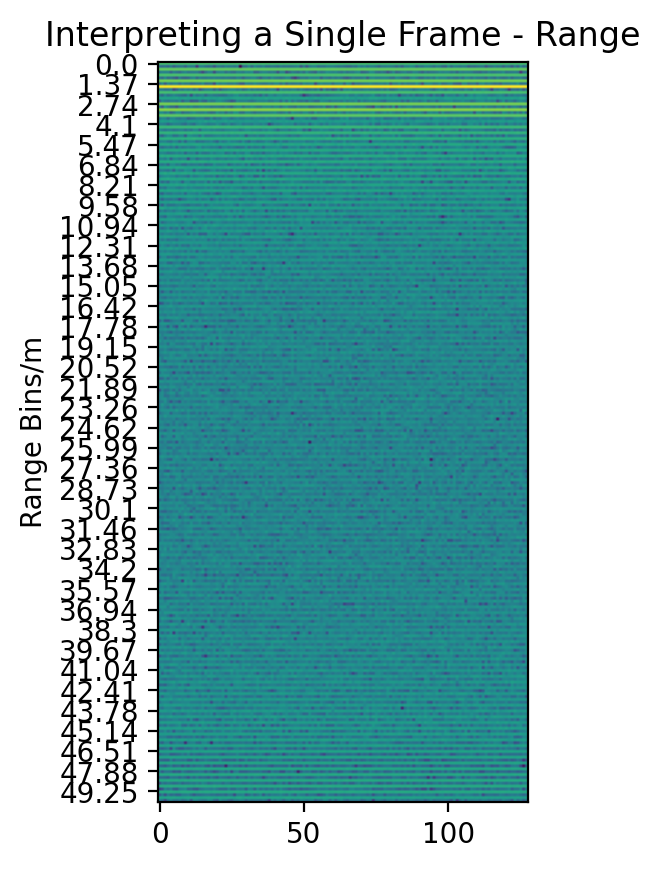

In [30]:
range_plot = np.fft.fft(adc_data[frame_index], axis=-1)
# Calculating bandwidth of the chirp, accounting for unit conversion
chirp_bandwidth = (ADC_PARAMS['freq_slope'] * 1e12 * ADC_PARAMS['samples']) / (ADC_PARAMS['sample_rate'] * 1e3)

# Using our derived equation for range resolution
range_res = 3e8 / (2 * chirp_bandwidth)
print(f'Range Resolution: {range_res} [meters]')

# Apply the range resolution factor to the range indices
ranges = np.round(np.arange(ADC_PARAMS['samples']) * range_res,2)

# Visualize Results
plt.imshow(np.log(np.abs(range_plot[:,0,:,:].sum(1)).T))
plt.ylabel('Range Bins/m')
plt.yticks(np.arange(ADC_PARAMS['samples'])[::7],ranges[::7])
plt.title('Interpreting a Single Frame - Range')
plt.show()

### 计算Doppler-FFT

In [31]:
window_d=np.kaiser(ADC_PARAMS['chirps'], 2)
range_plot_w=(range_plot.T*window_d).T

Velocity Resolution: 0.09511940432179009 [meters/sec]
Max Velocity: 6.0876418765945655 [meters/sec]


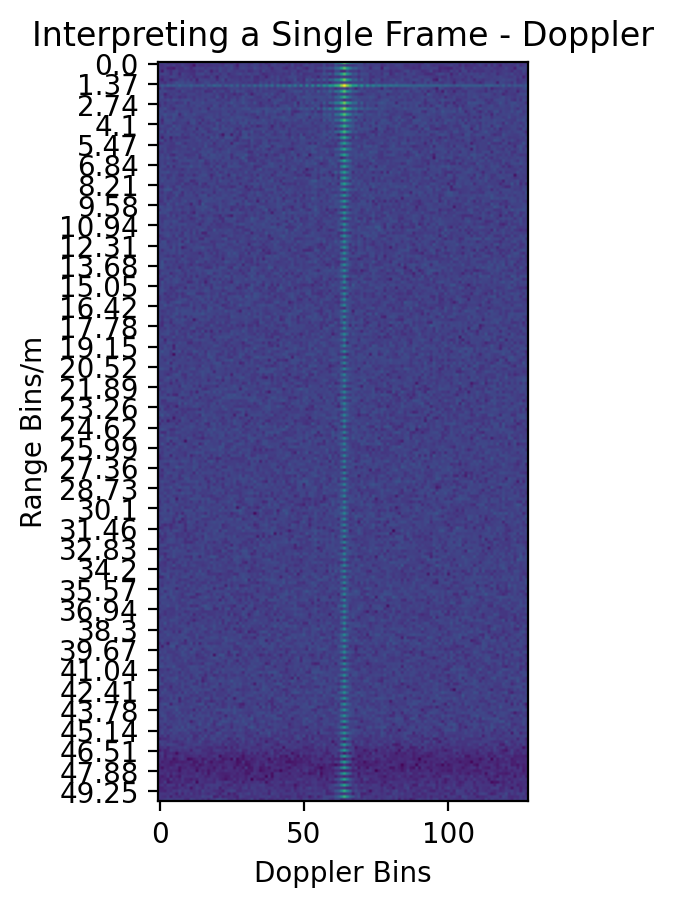

In [32]:
range_doppler = np.fft.fft(range_plot_w, axis=0)
range_doppler = np.fft.fftshift(range_doppler, axes=0)


StartWaveLenght = (3e8 / (ADC_PARAMS['startFreq'] * 1e9))
TimeChirp = 1e-6 *(ADC_PARAMS['idleTime'] + ADC_PARAMS['rampEndTime'])
TimeFrame = TimeChirp * ADC_PARAMS['chirps']
VelocityRes = (StartWaveLenght) / (2 * (TimeFrame))
print(f'Velocity Resolution: {VelocityRes} [meters/sec]')
MaxVelocity = StartWaveLenght / (4 * TimeChirp)
print(f'Max Velocity: {MaxVelocity} [meters/sec]')
# Visualize Results
plt.imshow(np.log(np.abs(range_doppler[:,0,:,:]).T).sum(1))
plt.xlabel('Doppler Bins')
plt.ylabel('Range Bins/m')
plt.yticks(np.arange(ADC_PARAMS['samples'])[::7],ranges[::7])
plt.title('Interpreting a Single Frame - Doppler')
plt.show()

shape of valid_indices: (256,)
shape of distance_bins_filtered: (128,)
shape of distance_fft_magnitude_filtered: (128,)
shape of ranges: (256,)
shape of distance_fft_magnitude: (128, 1, 4, 256)


ValueError: x and y must have same first dimension, but have shapes (256,) and (128,)

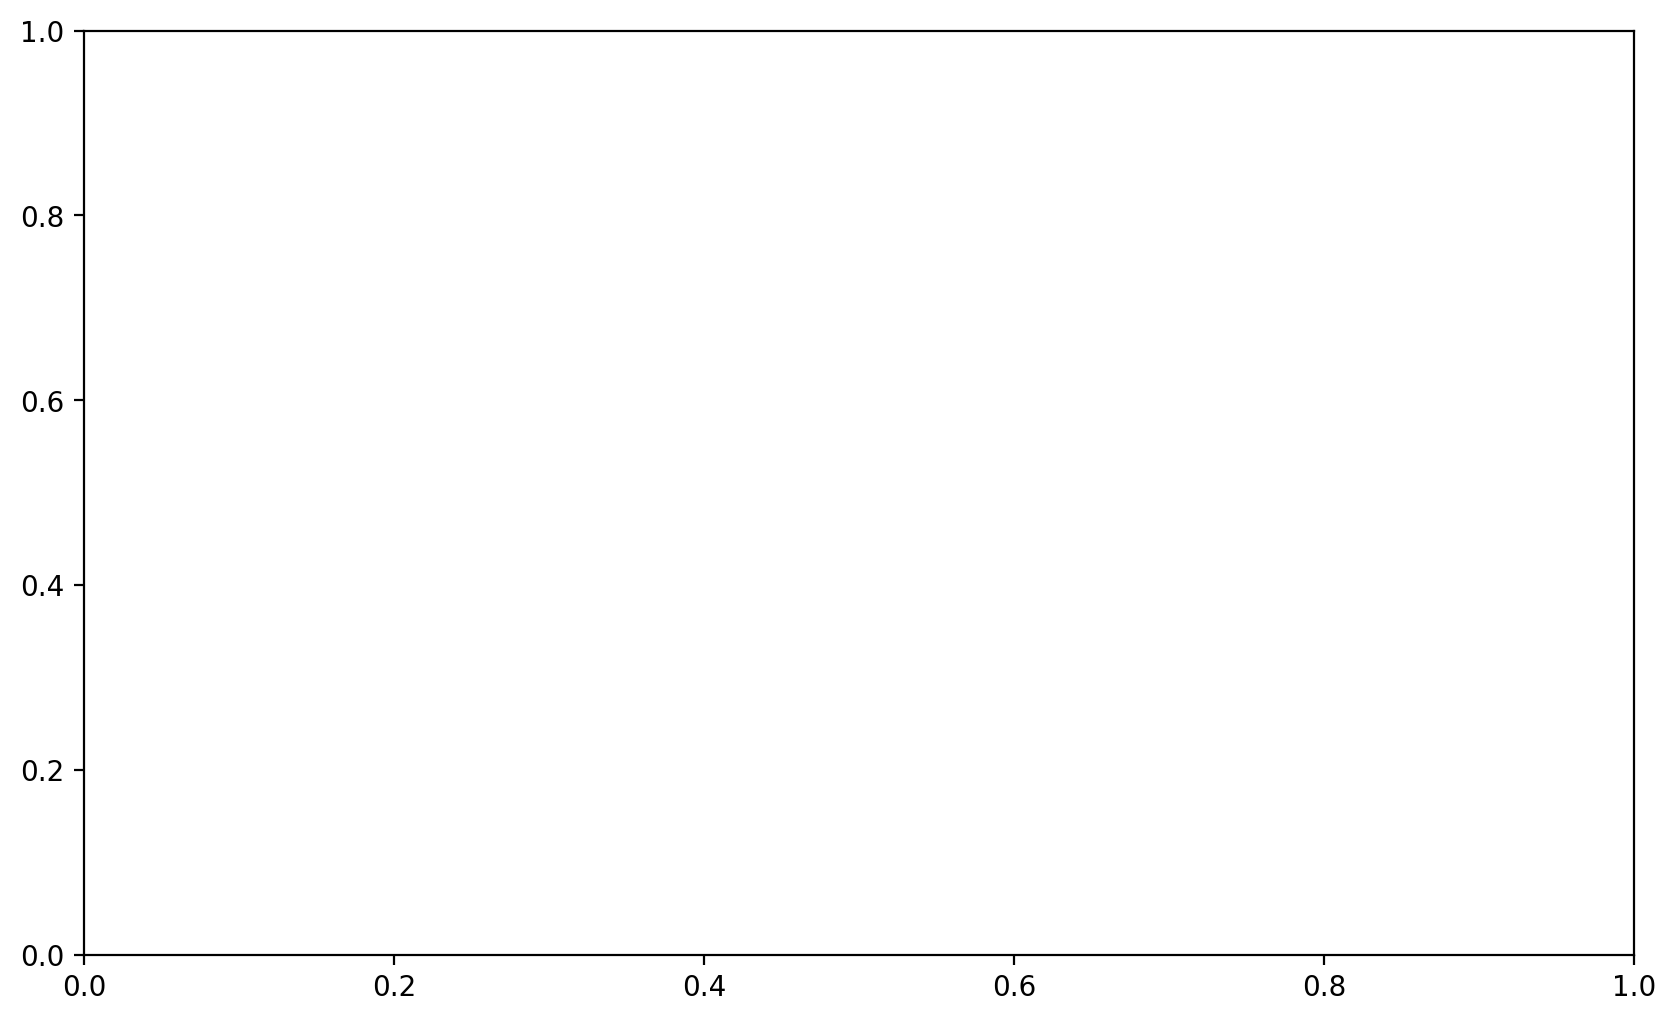

In [37]:
# Perform FFT on the distance data
distance_fft = np.fft.fft(adc_data[frame_index, :, :, :, :], axis=-1)
distance_fft_magnitude = np.abs(distance_fft)

# Calculate frequency bins
freq_bins = np.fft.fftfreq(ADC_PARAMS['samples'], d=1 / ADC_PARAMS['sample_rate'])
freq_bins = np.fft.fftshift(freq_bins)  # Shift zero frequency to the center

# Convert frequency bins to distance using the correct formula
distance_bins = (freq_bins * 3e8) / (2 * ADC_PARAMS['freq_slope'] * 1e12)  # Convert slope to Hz/s

chirp_bandwidth = (ADC_PARAMS['freq_slope'] * 1e12 * ADC_PARAMS['samples']) / (ADC_PARAMS['sample_rate'] * 1e3)
range_res = 3e8 / (2 * chirp_bandwidth)
ranges = np.round(np.arange(ADC_PARAMS['samples']) * range_res, 2)

# Filter data for the range 0 to 5 meters
valid_indices = (distance_bins >= 0) & (distance_bins <= 5)
distance_bins_filtered = distance_bins[valid_indices]
distance_fft_magnitude_filtered = np.fft.fftshift(distance_fft_magnitude[0, 0, 0, :])[valid_indices]

print(f"shape of valid_indices: {valid_indices.shape}")
print(f"shape of distance_bins_filtered: {distance_bins_filtered.shape}")
print(f"shape of distance_fft_magnitude_filtered: {distance_fft_magnitude_filtered.shape}")
print(f"shape of ranges: {ranges.shape}")
print(f"shape of distance_fft_magnitude: {distance_fft_magnitude.shape}")

# Convert magnitude to dB scale
distance_fft_magnitude_db = 20 * np.log10(distance_fft_magnitude_filtered + 1e-12)

# Plot the FFT magnitude for distance (0 to 5 meters) in dB
plt.figure(figsize=(10, 6))
plt.plot(ranges, distance_fft_magnitude_db, label="FFT Magnitude (dB)")
plt.xlabel("Distance (meters)")
plt.ylabel("Magnitude (dB)")
plt.title("FFT of Distance Data (0 to 5 meters)")
plt.legend()
plt.grid()
plt.show()

### 计算Azimuth-FFT

In [ ]:
# Convert rectangular image to circular (fan-shaped)
def fanScan(im, r0=0, angle=180, k=7, top=True):
    """
    Convert a rectangular image to a circular (fan-shaped) image.
    im          - Input 2D image
    angle       - Fan angle in degrees
    r0          - Inner circle radius; r0=0 outputs a sector
    k           - Interpolation density for neighboring points (increase k if white noise appears in the image)
    top         - Center of the circle at the top
    """
    h, w = im.shape  # Height and width of the input image

    if r0 > 0:  # If output is a ring, add background to the top of the image
        bg = np.zeros((r0, w))
        im = np.append(bg, im, axis=0) if top else np.append(im, bg, axis=0)

    h, w = im.shape  # Height and width after adding background
    r = 2 * h - 1    # Output image height and width
    im_fan = np.zeros((r, r))  # Create output image as a numpy array

    idx = np.arange(h) if top else np.arange(h)[::-1]
    alpha = np.radians(np.linspace(-angle / 2, angle / 2, k * w))  # Generate fan angle sequence
    for i in range(k * w):  # Iterate over each column of the input image
        rows = np.int32(np.ceil(np.cos(alpha[i]) * idx)) + r // 2
        cols = np.int32(np.ceil(np.sin(alpha[i]) * idx)) + r // 2
        im_fan[(rows, cols)] = im[:, i // k]

    if 360 > angle >= 180:  # Crop the blank area at the top of the output image
        im_fan = im_fan[int(h * (1 - np.sin(np.radians((angle / 2 - 90))))):]

    if not top:
        im_fan = im_fan[::-1]
    return im_fan

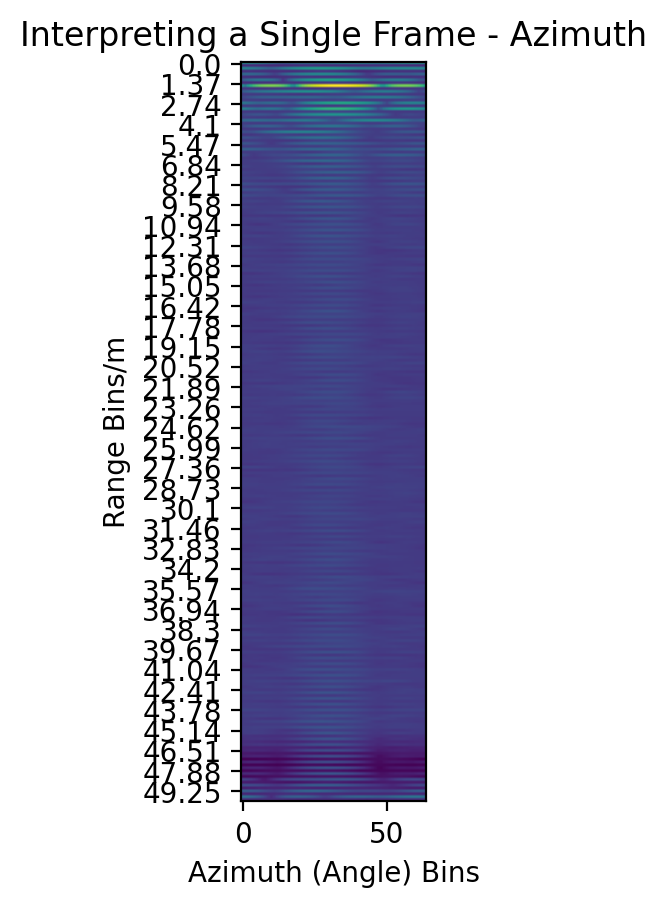

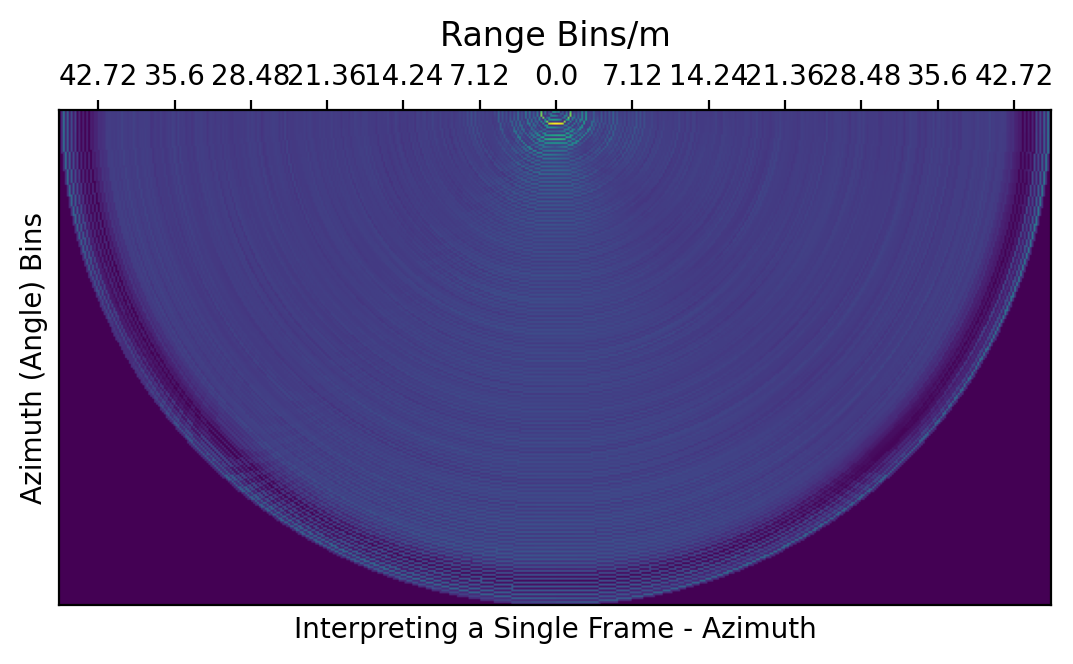

In [ ]:
num_angle_bins = 64

# Prepare azimuth data (take first 2 RX channels, reshape for FFT)
range_azimuth = range_plot_w[:, :2, :, :].reshape((ADC_PARAMS['chirps'], -1, ADC_PARAMS['samples']))
range_azimuth = np.fft.fft(range_azimuth, num_angle_bins, axis=1)
range_azimuth = np.fft.fftshift(range_azimuth, axes=1)

# Plot planar image
range_azimuth_img = np.log(np.abs(range_azimuth).sum(0).T)
range_azimuth_img = range_azimuth_img - np.min(range_azimuth_img)
range_azimuth_img = range_azimuth_img / np.max(range_azimuth_img)
plt.imshow(range_azimuth_img)
plt.xlabel('Azimuth (Angle) Bins')
plt.ylabel('Range Bins/m')
plt.yticks(np.arange(ADC_PARAMS['samples'])[::7], ranges[::7])
plt.title('Interpreting a Single Frame - Azimuth')
plt.show()

# Plot fan-shaped image
im_fan = fanScan(range_azimuth_img, r0=0, angle=180, k=50, top=True)
plt.imshow(im_fan)

# Move coordinate labels to the top
ax = plt.gca()
ax.xaxis.set_ticks_position('top')

# Annotate range
labelNum = 7  # Number of labels per side
range_xlabel = np.arange(0, ranges[-1], ranges[-1] / labelNum)
range_xlabel = np.round(np.concatenate((range_xlabel[:0:-1], range_xlabel)), 2)
range_xticks_l = np.arange((ADC_PARAMS['samples'] * 2 - 1) / 2, 0, -(ADC_PARAMS['samples'] * 2 - 1) / (2 * labelNum - 1))
range_xticks_h = np.arange((ADC_PARAMS['samples'] * 2 - 1) / 2, ADC_PARAMS['samples'] * 2 - 1, (ADC_PARAMS['samples'] * 2 - 1) / (2 * labelNum - 1))
range_xticks = np.concatenate((range_xticks_l[:0:-1], range_xticks_h))
plt.xticks(range_xticks, range_xlabel)

plt.yticks([])  # Remove y-axis ticks
plt.title('Range Bins/m')
plt.ylabel('Azimuth (Angle) Bins')
plt.xlabel('Interpreting a Single Frame - Azimuth')
plt.show()

In [36]:
def postProc(adc_data, adc_data2, ADC_PARAMS, adc_data2_label="adc_data2", frame_index=2, show_plots=True):
    """
    Full radar data post-processing: time-domain, range-FFT, Doppler-FFT, Azimuth-FFT.
    Saves all plots as PNGs. Optionally shows them interactively.
    adc_data2_label: label for adc_data2 in plots
    """

    # Reshape and parse ADC data
    adc_data = np.reshape(adc_data, (-1, ADC_PARAMS['chirps'], ADC_PARAMS['tx'], ADC_PARAMS['samples'], ADC_PARAMS['IQ'], ADC_PARAMS['rx']))
    adc_data = np.transpose(adc_data, (0, 1, 2, 5, 3, 4))
    adc_data = (1j * adc_data[..., 1] + adc_data[..., 0]).astype(np.complex64)
   
    # Reshape and parse ADC data2
    if adc_data2 is None:
        adc_data2 = adc_data.copy()
    adc_data2 = np.reshape(adc_data2, (-1, ADC_PARAMS['chirps'], ADC_PARAMS['tx'], ADC_PARAMS['samples'], ADC_PARAMS['IQ'], ADC_PARAMS['rx']))
    adc_data2 = np.transpose(adc_data2, (0, 1, 2, 5, 3, 4))
    adc_data2 = (1j * adc_data2[..., 1] + adc_data2[..., 0]).astype(np.complex64)
    
    # Select frame
    if frame_index < 0 or frame_index >= adc_data.shape[0]:
        raise IndexError(f"frame_index {frame_index} out of range (0-{adc_data.shape[0]-1})")
    frame = adc_data[frame_index]
    frame2 = adc_data2[frame_index]

    # Range-FFT
    window = np.kaiser(ADC_PARAMS['samples'], 4)
    frame_win = frame * window
    frame_win2 = frame2 * window
    range_fft = np.fft.fft(frame_win, axis=-1)
    range_fft2 = np.fft.fft(frame_win2, axis=-1)

    # Range resolution and bins
    chirp_bandwidth = (ADC_PARAMS['freq_slope'] * 1e12 * ADC_PARAMS['samples']) / (ADC_PARAMS['sample_rate'] * 1e3)
    range_res = 3e8 / (2 * chirp_bandwidth)
    ranges = np.round(np.arange(ADC_PARAMS['samples']) * range_res, 2)

    chirp_bandwidth_1200 = (57.93571472167969 * 1e12 * ADC_PARAMS['samples']) / (ADC_PARAMS['sample_rate'] * 1e3)
    range_res_1200 = 3e8 / (2 * chirp_bandwidth_1200)
    ranges_1200 = np.round(np.arange(ADC_PARAMS['samples']) * range_res_1200, 2)

   
    # --- Add Range Profile FFT Plot ---
    range_profile = np.abs(range_fft).sum(axis=(0,1,2))
    range_profile_db = 20 * np.log10(range_profile + 1e-12)
    range_profile_2 = np.abs(range_fft2).sum(axis=(0,1,2))
    range_profile_db2 = 20 * np.log10(range_profile_2 + 1e-12)

    plt.figure(figsize=(10, 6))
    plt.plot(ranges, range_profile_db, color='b', linewidth=1, label='chair at 5m')
    # You can use any valid matplotlib color name or shortcut letter.
    # Common color names: 'blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'yellow', 'black'
    # Shortcut letters: 'b' (blue), 'g' (green), 'r' (red), 'c' (cyan), 'm' (magenta), 'y' (yellow), 'k' (black), 'w' (white)
    plt.plot(ranges, range_profile_db2, color='g', linewidth=1, label=adc_data2_label)
    plt.legend()
    plt.title(f"Range Profile FFT")
    plt.xlabel("Range (m)")
    plt.ylabel("Magnitude (dB)")
    plt.grid(True)
    if show_plots: plt.show()
    plt.close()

    # Plot Range-FFT (sum over tx, rx)
    plt.figure(figsize=(10,7))
    plt.imshow(np.log(np.abs(range_fft2[:,0,:,:].sum(1)).T), aspect='auto')
    plt.xlabel('Chirps')
    plt.ylabel('Range Bins/m')
    plt.yticks(np.arange(ADC_PARAMS['samples'])[::7], ranges_1200[::7])
    plt.title(f'Range FFT - {adc_data2_label}')
    plt.colorbar(label='log(magnitude)')
    if show_plots: plt.show()
    plt.close()

In [47]:
adc_filename = "clean.bin"
adc2_filename = "2blocks.bin" 
adc3_filename = "chair_5m_1200.bin" 
frame_index = 2  

adc_data = np.fromfile(adc_filename, dtype=np.int16)
adc_data2 = np.fromfile(adc2_filename, dtype=np.int16)
# adc_data3 = np.fromfile(adc3_filename, dtype=np.int16)
from mmwave.dataloader import DCA1000
_,_,ADC_PARAMS,_=DCA1000.AWR2243_read_config("configFiles/AWR2243_mmwaveconfig.txt")
print(ADC_PARAMS)

{'chirps': 128, 'rx': 4, 'tx': 1, 'samples': 128, 'IQ': 2, 'bytes': 2, 'startFreq': 77.00025880336761, 'idleTime': 5.0, 'adc_valid_start_time': 6.0, 'rampEndTime': 20.0, 'freq_slope': 39.975643157958984, 'txStartTime': 0.0, 'sample_rate': 10000, 'frame_periodicity': 70.0}


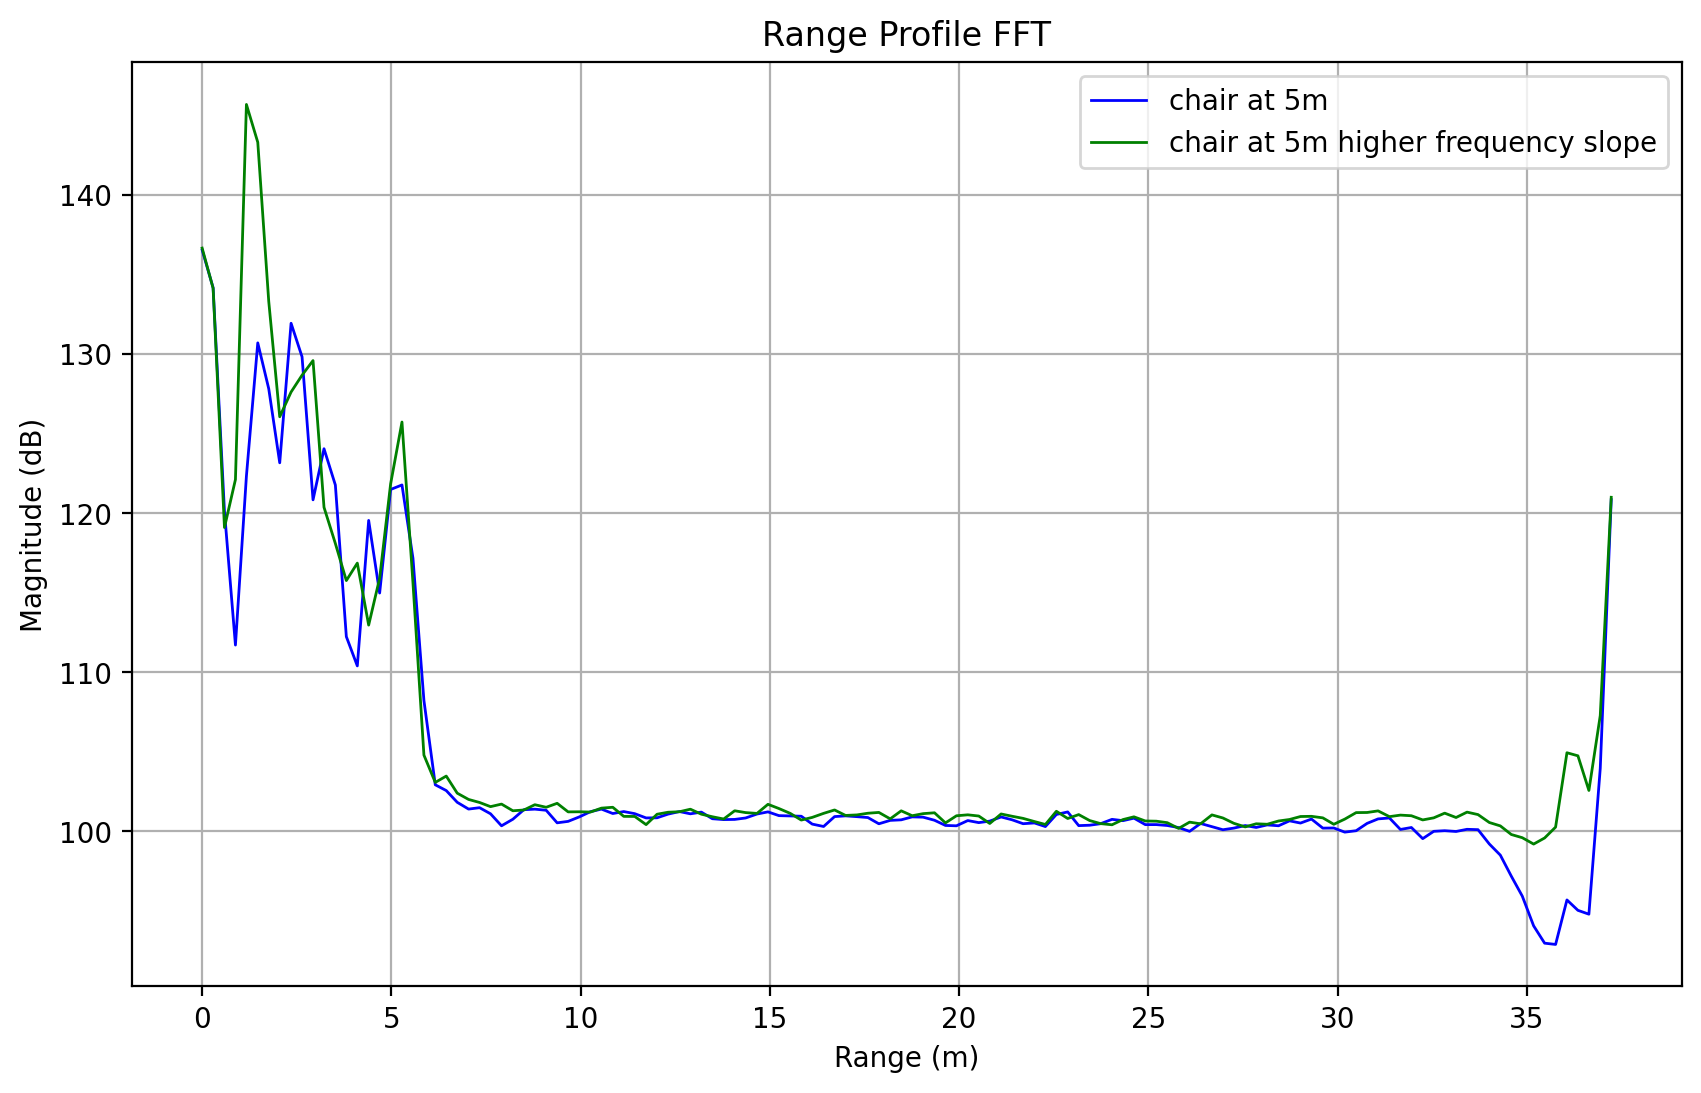

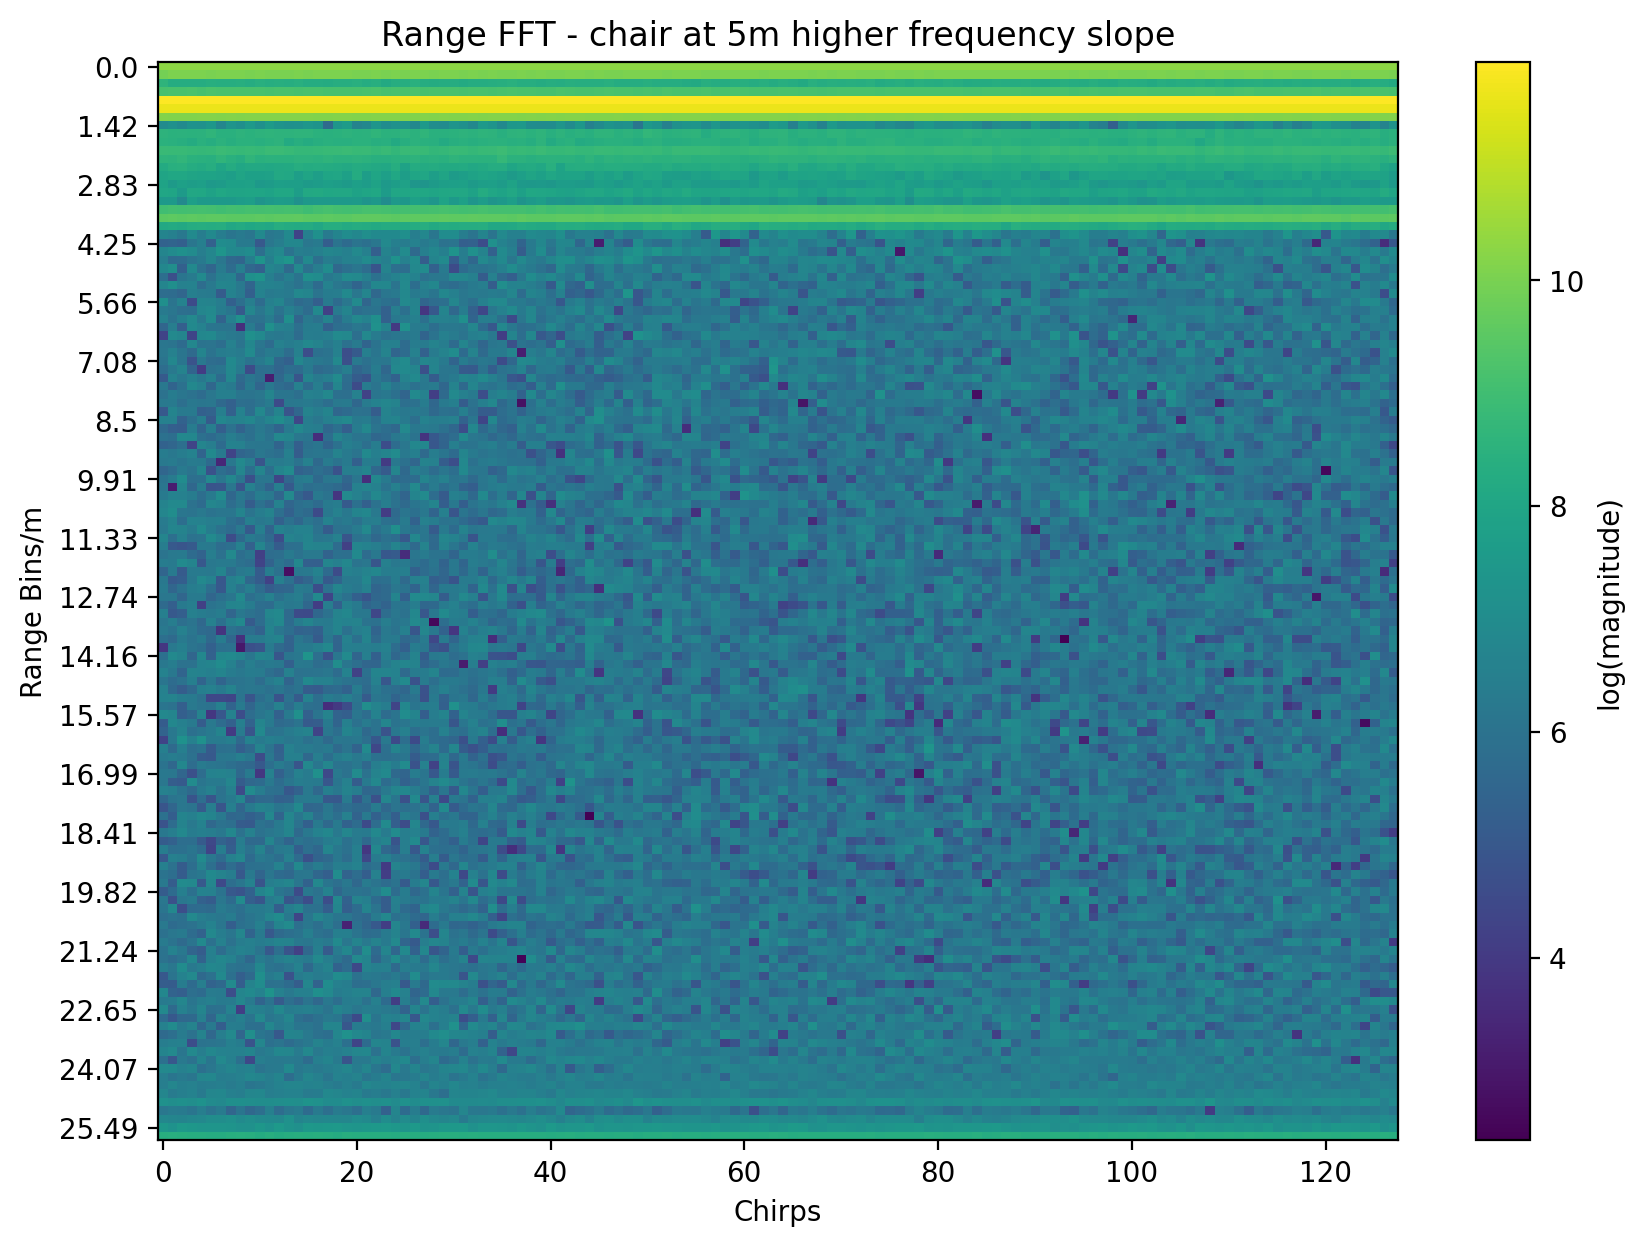

In [48]:
postProc(adc_data,adc_data2,ADC_PARAMS,"chair at 5m higher frequency slope")